# Single-Shot Signal Viewer

Set a shot number, run the notebook, and it will fetch and plot the requested signals.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDSplus

from gadata import gadata

def filter_lp(x, prev_y, dt, tau):
    """
    Low-pass filter function.
    
    Args:
        x: Current input value
        prev_y: Previous filtered output value
        dt: Time step
        tau: Time constant (filter strength)
    
    Returns:
        Filtered output value
    """
    return prev_y + dt / (dt + tau) * (x - prev_y)

def apply_lp_filter(data, dt, tau):
    """
    Apply low-pass filter to an array of data.
    
    Args:
        data: Input data array
        dt: Time step (or can be an array of time differences)
        tau: Time constant (controls filter strength)
    
    Returns:
        Filtered data array
    """
    filtered = np.zeros_like(data)
    filtered[0] = data[0]  # Initialize with first value
    
    for i in range(1, len(data)):
        filtered[i] = filter_lp(data[i], filtered[i-1], dt, tau)
    
    return filtered

In [18]:
shot = 206594

signals = [
    'bmspinj30l',
    'bmspinj30r',
    'bmspinj33l',
    'bmspinj33r',
    'bmspinj15l',
    'bmspinj15r',
    'bmspinj21l',
    'bmspinj21r',
    'gasA',
    'echpwrc',
]

In [19]:
conn = MDSplus.Connection('atlas.gat.com')

def fetch_signal(signal_name, shot_number, connection):
    try:
        data = gadata(signal_name, shot_number, connection=connection)
        x = np.asarray(data.xdata)
        y = np.asarray(data.zdata)

        if x.ndim == 0 or y.ndim == 0 or x.size <= 1 or y.size <= 1:
            raise ValueError('Signal returned no time trace')

        return {
            'signal': signal_name,
            'x': x,
            'y': y,
            'xunits': str(data.xunits),
            'yunits': str(data.zunits),
            'ok': True,
            'error': '',
        }
    except Exception as exc:
        return {
            'signal': signal_name,
            'x': np.array([]),
            'y': np.array([]),
            'xunits': '',
            'yunits': '',
            'ok': False,
            'error': str(exc),
        }

results = [fetch_signal(signal, shot, conn) for signal in signals]

   bmspinj30l fetched from PTDATA in 2.19s
   bmspinj30r fetched from PTDATA in 0.07s
   bmspinj33l fetched from PTDATA in 0.07s
   bmspinj33r fetched from PTDATA in 0.07s
   bmspinj15l fetched from PTDATA in 0.08s
   bmspinj15r fetched from PTDATA in 0.07s
   bmspinj21l fetched from PTDATA in 0.06s
   bmspinj21r fetched from PTDATA in 0.07s
   gasA fetched from PTDATA in 1.13s
   echpwrc fetched from MDSplus tree RF in 0.02s


In [20]:
summary = pd.DataFrame(
    [
        {
            'signal': result['signal'],
            'status': 'ok' if result['ok'] else 'missing',
            'points': len(result['y']),
            'units': result['yunits'],
            'error': result['error'],
        }
        for result in results
    ]
)

summary

,signal,status,points,units,error
0,bmspinj30l,ok,152496,,
1,bmspinj30r,ok,152496,,
2,bmspinj33l,ok,152496,,
3,bmspinj33r,ok,152496,,
4,bmspinj15l,ok,152496,,
5,bmspinj15r,ok,152496,,
6,bmspinj21l,ok,152496,,
7,bmspinj21r,ok,152496,,
8,gasA,ok,2097152,,
9,echpwrc,ok,205000,W,


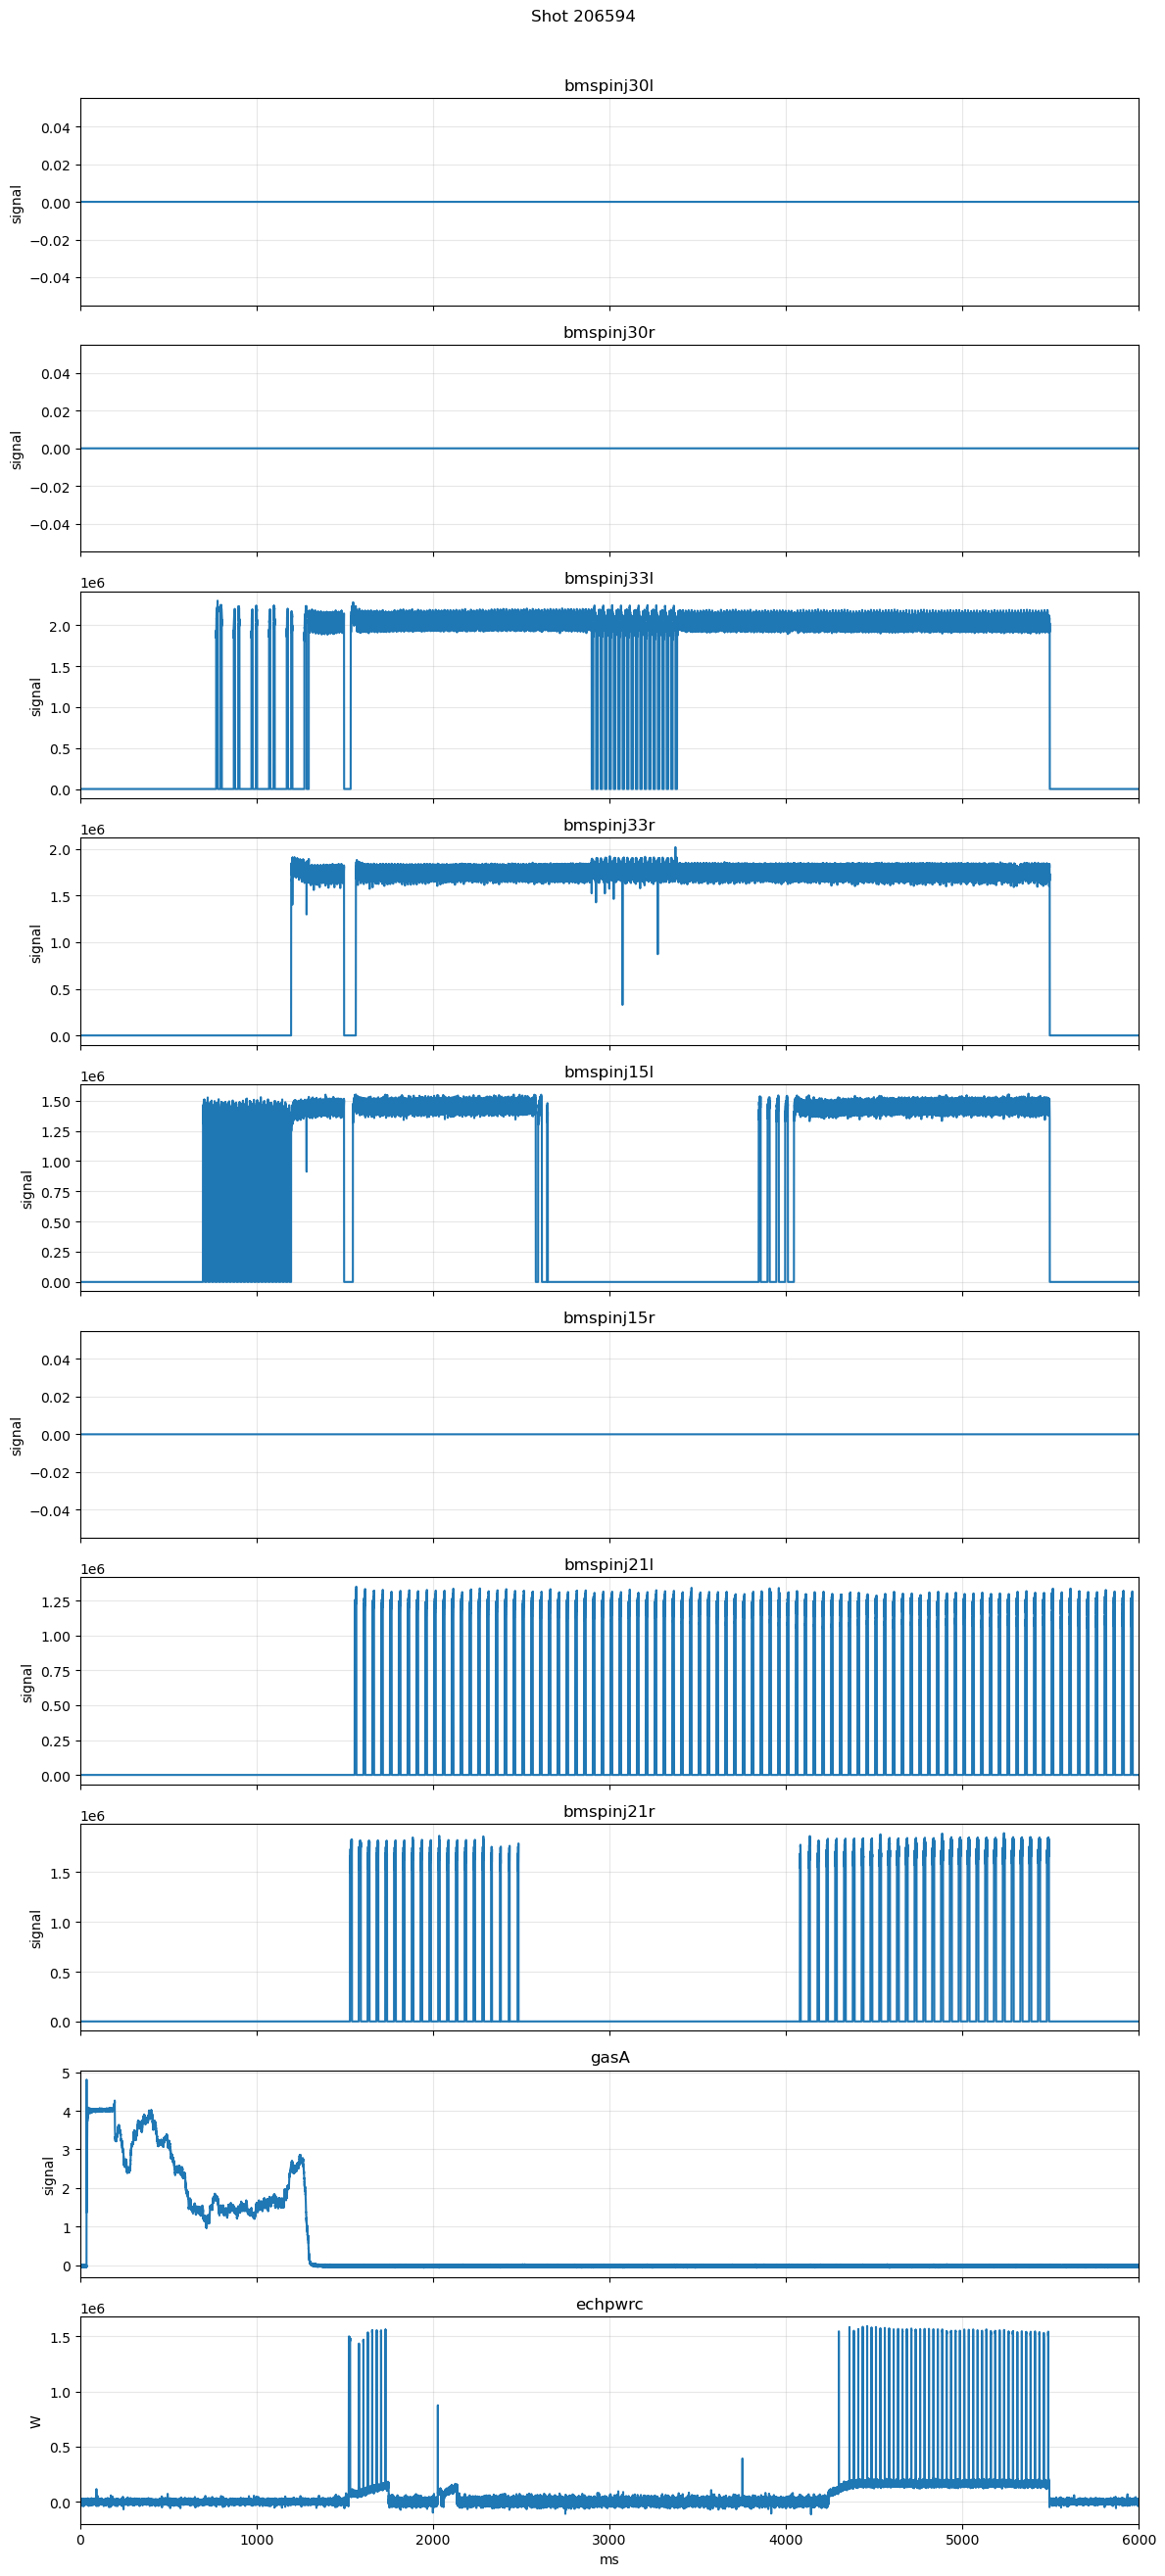

In [21]:
valid_results = [result for result in results if result['ok']]

x_limits = (0, 6000)

if not valid_results:
    raise RuntimeError(f'No requested signals were fetched for shot {shot}.')

fig, axes = plt.subplots(len(valid_results), 1, figsize=(12, 2.6 * len(valid_results)), sharex=True)
axes = np.atleast_1d(axes)

for axis, result in zip(axes, valid_results):
    filter_signal = apply_lp_filter(result['x'], dt = 1, tau = 100)
    axis.plot(filter_signal, result['y'], linewidth=1.5)
    axis.set_xlim(x_limits)
    ylabel = result['yunits'] if result['yunits'] not in ['', 'None'] else 'signal'
    axis.set_ylabel(ylabel)
    axis.set_title(result['signal'])
    axis.grid(True, alpha=0.3)

xlabel = valid_results[-1]['xunits'] if valid_results[-1]['xunits'] not in ['', 'None'] else 'time'
axes[-1].set_xlabel(xlabel)
fig.suptitle(f'Shot {shot}', y=1.01)
fig.tight_layout()
plt.show()